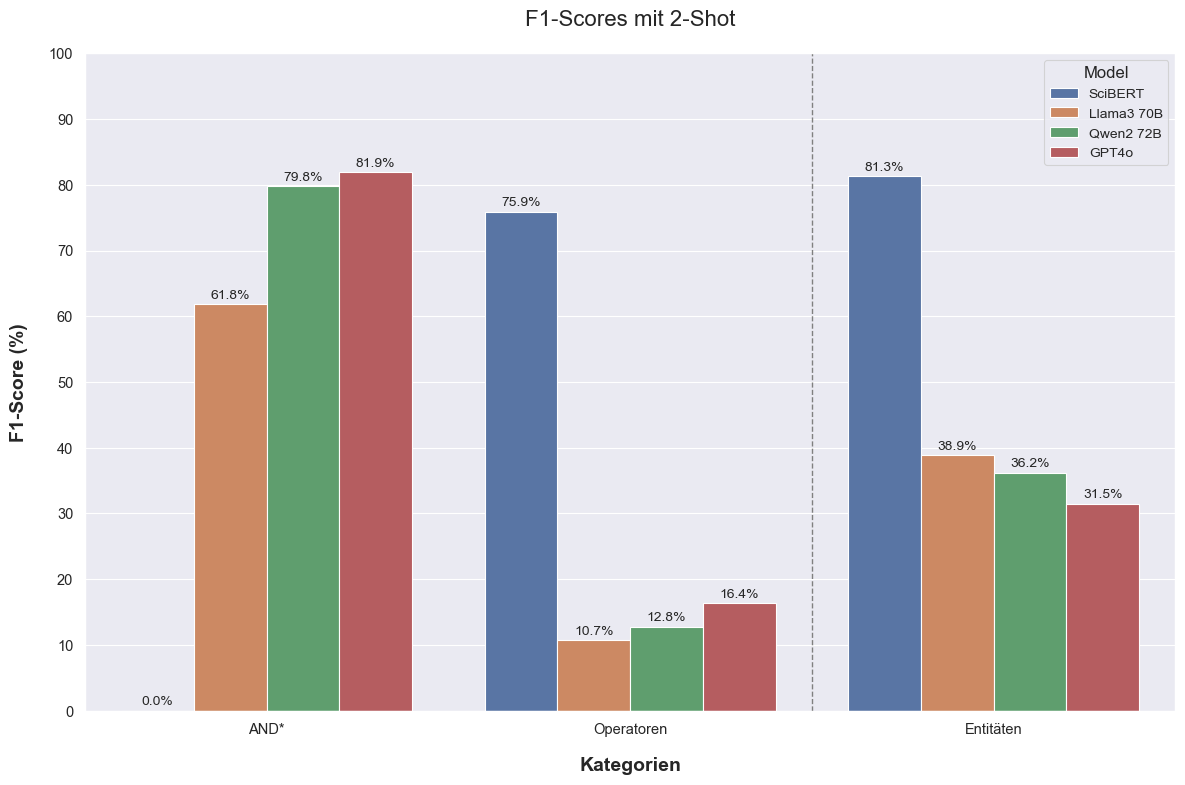

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_f1_scores_comparison_seaborn(operator_metrics, entity_metrics):
    # Prepare the data
    data = []
    for model in operator_metrics.keys():
        data.append({'Model': model, 'Category': 'AND*', 'F1-Score': operator_metrics[model]['AND*']})
        data.append({'Model': model, 'Category': 'Operatoren', 'F1-Score': operator_metrics[model]['Durchschnitt']})
        data.append({'Model': model, 'Category': 'Entitäten', 'F1-Score': entity_metrics[model]})

    df = pd.DataFrame(data)

    # Set up the plot
    sns.set_theme(style="darkgrid")
    sns.set_context("paper", font_scale=1.2)
    plt.figure(figsize=(12, 8))

    # Create the grouped bar plot
    ax = sns.barplot(x='Category', y='F1-Score', hue='Model', data=df, palette='deep')

    # Customize the plot
    plt.title('F1-Scores mit 2-Shot', fontsize=16, pad=20)
    plt.xlabel('Kategorien', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel('F1-Score (%)', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylim(0, 100)
    plt.yticks(np.arange(0, 101, 10))

    # Add percentage labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=10, padding=2)

    # Adjust legend
    plt.legend(title='Model', title_fontsize='12', fontsize='10', loc='best')

    # Add separator line before "Entitäten"
    plt.axvline(x=1.5, color='gray', linestyle='--', linewidth=1)

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig('pics/2_shot.png', bbox_inches='tight')
    plt.show()

# Updated data for 2-Shot from the tables
operator_metrics = {
    'SciBERT': {'AND*': 0.0, 'Durchschnitt': 75.9},
    'Llama3 70B': {'AND*': 61.8, 'Durchschnitt': 10.7},
    'Qwen2 72B': {'AND*': 79.8, 'Durchschnitt': 12.8},
    'GPT4o': {'AND*': 81.9, 'Durchschnitt': 16.4}
}

entity_metrics = {
    'SciBERT': 81.3,
    'Llama3 70B': 38.9,
    'Qwen2 72B': 36.2,
    'GPT4o': 31.5
}

plot_f1_scores_comparison_seaborn(operator_metrics, entity_metrics)

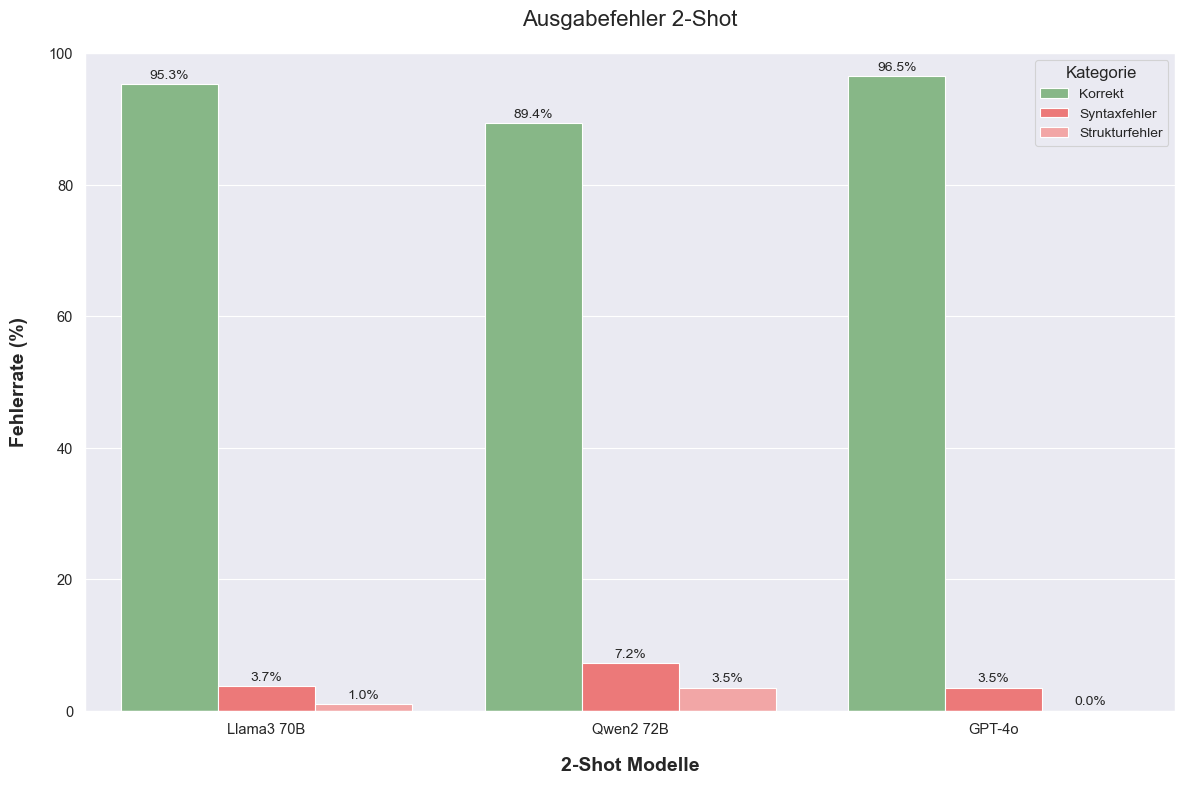

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_ausgabefehler_seaborn(error_data):
    df = pd.DataFrame(error_data)
    df_melted = pd.melt(df, id_vars=['Kategorie'], var_name='Model', value_name='Percentage')

    # Set the style to the default Seaborn style
    sns.set_theme(style="darkgrid")
    sns.set_context("paper", font_scale=1.2)

    plt.figure(figsize=(12, 8))
    colors = ['#7FBF7F', '#FF6666', '#FF9999']  # Green for correct, dark red for syntax error, light red for structure error
    ax = sns.barplot(x='Model', y='Percentage', hue='Kategorie', data=df_melted, palette=colors)

    plt.title('Ausgabefehler 2-Shot', fontsize=16, pad=20)
    plt.xlabel('2-Shot Modelle', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel('Fehlerrate (%)', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylim(0, 100)

    # Add percentage labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=10, padding=2)

    # Adjust legend
    plt.legend(title='Kategorie', title_fontsize='12', fontsize='10', loc='best')

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig('pics/2_shot_ausgabefehler.png', bbox_inches='tight', dpi=300, facecolor='auto', edgecolor='auto')
    plt.show()

# Updated data from the 2-Shot table
error_data = {
    'Kategorie': ['Korrekt', 'Syntaxfehler', 'Strukturfehler'],
    'Llama3 70B': [95.3, 3.7, 1.0],
    'Qwen2 72B': [89.4, 7.2, 3.5],
    'GPT-4o': [96.5, 3.5, 0.0]
}

plot_ausgabefehler_seaborn(error_data)

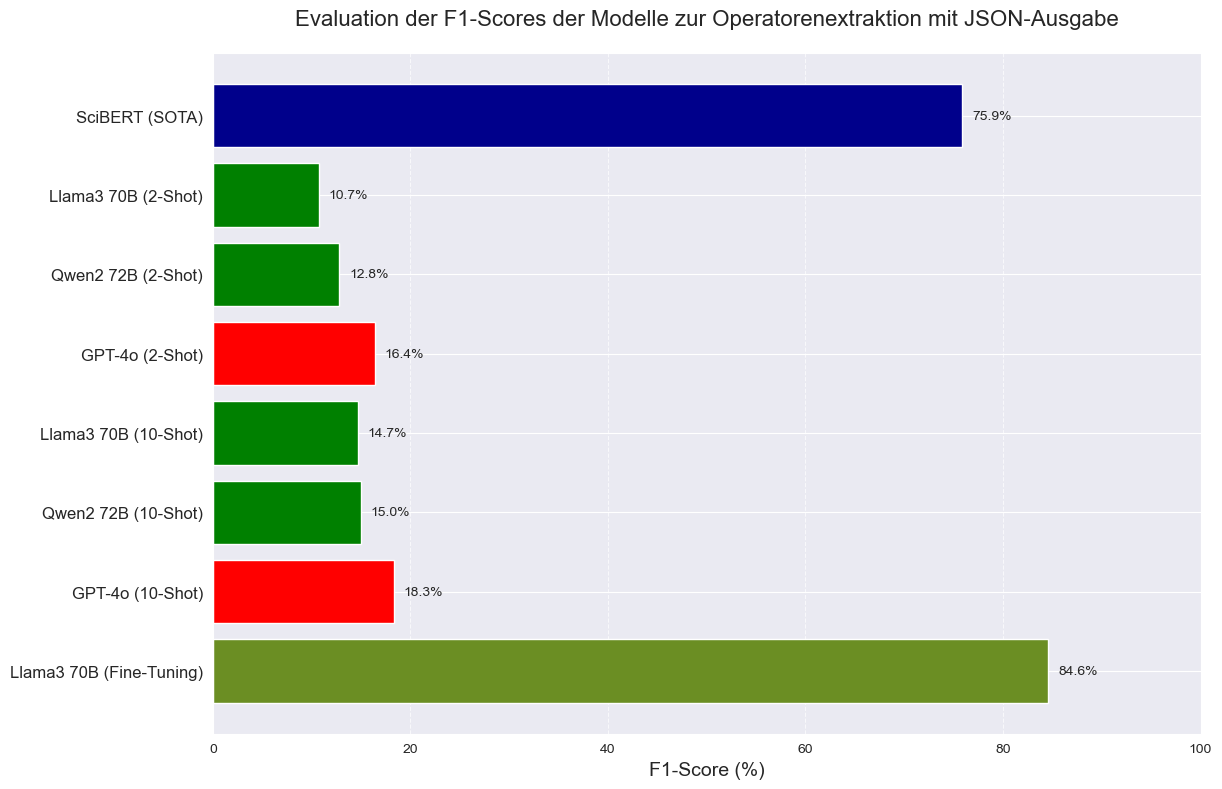

In [10]:
import matplotlib.pyplot as plt


models_corrected = [
    "SciBERT (SOTA)",
    "Llama3 70B (2-Shot)",
    "Qwen2 72B (2-Shot)",
    "GPT-4o (2-Shot)",
    "Llama3 70B (10-Shot)",
    "Qwen2 72B (10-Shot)",
    "GPT-4o (10-Shot)",
    "Llama3 70B (Fine-Tuning)"
]

# Die F1-Scores in der entsprechenden Reihenfolge
f1_scores_corrected = [75.9, 10.7, 12.8, 16.4, 14.7, 15.0, 18.3, 84.6]

# Farben entsprechend der Kategorien
colors_corrected = ['darkblue', 'green', 'green', 'red', 'green', 'green', 'red', 'olivedrab']

# Liste umkehren, damit SciBERT oben und Fine-Tuning unten ist
models_corrected.reverse()
f1_scores_corrected.reverse()
colors_corrected.reverse()

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(models_corrected, f1_scores_corrected, color=colors_corrected)

# Hinzufügen der Werte an die Balken
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.1f}%', va='center', fontsize=10)

# Achsenbeschriftungen und Titel
ax.set_xlabel('F1-Score (%)', fontsize=14)
ax.set_title('Evaluation der F1-Scores der Modelle zur Operatorenextraktion mit JSON-Ausgabe', fontsize=16, pad=20)
ax.set_xlim(0, 100)

# Wissenschaftliche Anpassungen
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Increase font size for y-axis labels
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=10)

# Save as SVG
plt.savefig('op_eval.svg', format='svg', bbox_inches='tight')

# Plot anzeigen
plt.show()


color_palette = {
    'SOTA': '#1f77b4',       # Blau: typischer wissenschaftlicher Farbton, gut unterscheidbar
    'Open': '#2ca02c',       # Grün: gut sichtbar, für "Open" sinnvoll
    'Closed': '#d62728'      # Rot: symbolisch für "Closed", hoher Kontrast
}